In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import os
import joblib

# to generate the graph
import matplotlib.pyplot as plt

In [6]:
# ─── Step 1: Load and Clean ───────────────────────────────────
df_train = pd.read_csv("Train.csv")
df_test = pd.read_csv("Test.csv")

In [7]:
education_map = {
    "Preschool": 1, "1st-4th": 2, "5th-6th": 3, "7th-8th": 4,
    "9th": 5, "10th": 6, "11th": 7, "12th": 8, "HS-grad": 9,
    "Some-college": 10, "Assoc-voc": 11, "Assoc-acdm": 12,
    "Bachelors": 13, "Masters": 14, "Prof-school": 15, "Doctorate": 16
}

In [8]:
# Standardize column names
df_test = df_test.rename(columns={
    "workclass": "work-class",
    "fnlwgt":    "work-fnl",
    "occupation":"position"
})

In [9]:
# Remove duplicates
df_train = df_train.drop_duplicates()
df_test  = df_test.drop_duplicates()

In [10]:
# Handle hidden nulls (' ?') then strip ALL string columns
df_train.replace(" ?", np.nan, inplace=True)
df_test.replace(" ?", np.nan, inplace=True)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

✅ Strip leading/trailing spaces from every string column

In [11]:
for col in df_train.select_dtypes(include='object').columns:
    df_train[col] = df_train[col].str.strip()
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].str.strip()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_8496\132763074.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_train.select_dtypes(include='object').columns:
C:\Users\ahmed\AppData\Local\Temp\ipykernel_8496\132763074.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guid

In [12]:
# Encode target
target = "salary"
le = LabelEncoder()
df_train["salary"] = le.fit_transform(df_train["salary"])
df_test["salary"]  = le.transform(df_test["salary"])

heatmap for coreallation((edu-num, age, capitalgain and loss, work fnl,'sex', 'race', 'native-country', 'work-class ))vs salary)// after encoding
histogram for , 'sex', 'race', 'native-country// after encoding
confusion matrix// after model training for each model



# Drop unused columns


In [13]:
#education useless as we have education num column
drop_cols = ['work-fnl', 'education', 'sex', 'race', 'native-country', 'work-class']
df_train.drop(drop_cols, axis=1, inplace=True)
df_test.drop(drop_cols,  axis=1, inplace=True)
onehot_cols  = ["marital-status", "position", "relationship"]
cols_to_scale = ['capital-gain', 'capital-loss', 'age', 'hours-per-week']

In [14]:
# Scale numeric columns
scaler = MinMaxScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale]  = scaler.transform(df_test[cols_to_scale])

In [15]:
# One-hot encode categorical columns
train_size = len(df_train)
combined   = pd.concat([df_train, df_test], axis=0)
combined   = pd.get_dummies(combined, columns=onehot_cols).astype(int)
df_train   = combined.iloc[:train_size]
df_test    = combined.iloc[train_size:]

In [16]:
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_test  = df_test.drop(columns=[target])
y_test  = df_test[target]

In [33]:
# ─── ✅ FIX: Apply SMOTE to balance the training set ─────────
print("⚖️  Balancing training data with SMOTE...")
print(f"   Before → {dict(zip(*np.unique(y_train, return_counts=True)))}")

⚖️  Balancing training data with SMOTE...
   Before → {np.int64(0): np.int64(15902), np.int64(1): np.int64(5206)}


In [18]:
sm = SMOTE(random_state=42, sampling_strategy=0.5)  # Balance to 50% minority class
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

   After  → {np.int64(0): np.int64(15902), np.int64(1): np.int64(7951)}



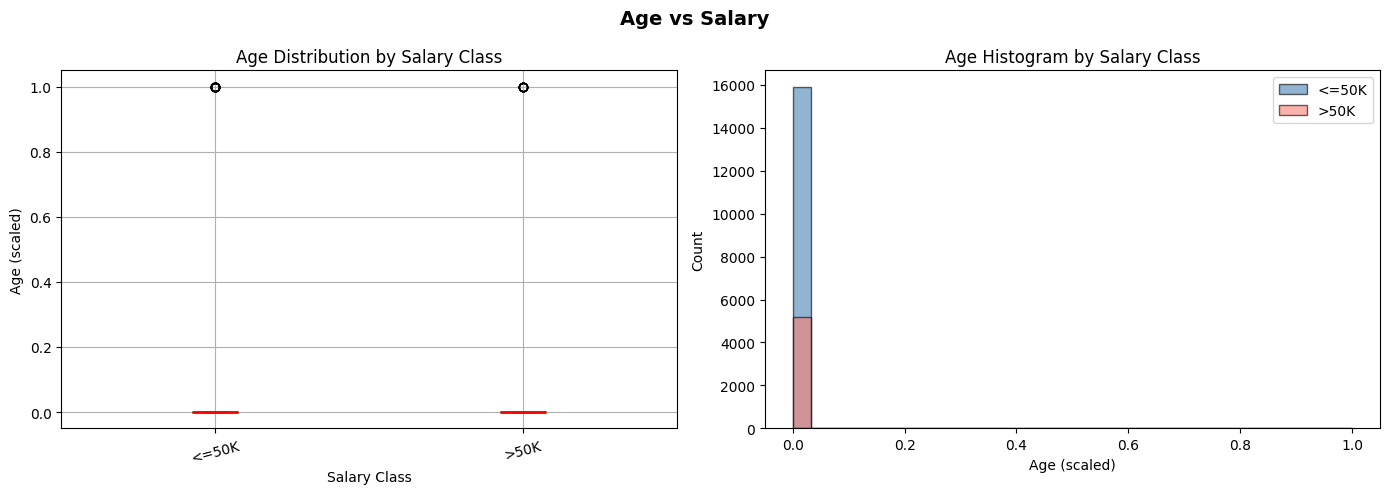

In [32]:
# first vis
print(f"   After  → {dict(zip(*np.unique(y_train_bal, return_counts=True)))}\n")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decode salary back to labels for readability
age_salary = pd.DataFrame({
    'age':    X_train['age'],
    'salary': y_train.map({i: cls for i, cls in enumerate(le.classes_)})
})

# Box plot
age_salary.boxplot(column='age', by='salary', ax=axes[0],
                   patch_artist=True,
                   boxprops=dict(facecolor='steelblue', color='black'),
                   medianprops=dict(color='red', linewidth=2))
axes[0].set_title("Age Distribution by Salary Class")
axes[0].set_xlabel("Salary Class")
axes[0].set_ylabel("Age (scaled)")
plt.sca(axes[0])
plt.xticks(rotation=15)

# Histogram overlay
for label, color in zip(le.classes_, ['steelblue', 'salmon']):
    subset = age_salary[age_salary['salary'] == label]['age']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black')

axes[1].set_title("Age Histogram by Salary Class")
axes[1].set_xlabel("Age (scaled)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.suptitle("Age vs Salary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("age_vs_salary.png", dpi=150)
plt.show()

In [20]:
# ─── Step 6: Train & Evaluate ────────────────────────────────
models = {
   "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=0.5),
   "Decision Tree": DecisionTreeClassifier(random_state=30, max_depth=10, min_samples_split=10, min_samples_leaf=4),
   "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, max_depth=15, min_samples_split=10),
   "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance', metric='manhattan'),
   "SVM": SVC(random_state=42, kernel='rbf', C=0.8, gamma='scale'),
}

In [21]:
trained_models = {name: model for name, model in models.items()}

In [22]:
print("📊 Training Models...\n")
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    trained_models[name] = model

    print(f"{'='*50}")
    print(f"  {name}  |  Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

📊 Training Models...

  Logistic Regression  |  Accuracy: 0.8217
              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.88      6737
        >50K       0.65      0.63      0.64      2302

    accuracy                           0.82      9039
   macro avg       0.77      0.76      0.76      9039
weighted avg       0.82      0.82      0.82      9039

  Decision Tree  |  Accuracy: 0.8103
              precision    recall  f1-score   support

       <=50K       0.89      0.85      0.87      6737
        >50K       0.61      0.70      0.65      2302

    accuracy                           0.81      9039
   macro avg       0.75      0.77      0.76      9039
weighted avg       0.82      0.81      0.81      9039

  Random Forest  |  Accuracy: 0.8173
              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      6737
        >50K       0.64      0.65      0.64      2302

    accuracy                           0.82

delete from here

In [23]:
# ─── User Input & Prediction ─────────────────────────────────
print("\n🔮 Prediction Mode")
print("Available models:")
for i, name in enumerate(trained_models.keys()):
    print(f"  {i+1}. {name}")


🔮 Prediction Mode
Available models:
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. KNN
  5. SVM


In [24]:
model_choice  = int(input("\nChoose a model (enter number): ")) - 1
chosen_name   = list(trained_models.keys())[model_choice]
chosen_model  = trained_models[chosen_name]
print(f"\n✅ Using: {chosen_name}")


✅ Using: Logistic Regression


In [25]:
print("\nEnter the following details:")
age            = float(input("Age: "))
education = input("education (e.g. Doctorate, Prof-school, Masters, Bachelors): ")
capital_gain   = float(input("Capital gain: "))
capital_loss   = float(input("Capital loss: "))
hours_per_week = float(input("Hours per week: "))


Enter the following details:


In [26]:
education_num=education_map.get(education)

In [27]:
print("\nMarital status options:")
marital_options = ["Married-civ-spouse", "Never-married", "Divorced",
                   "Separated", "Widowed", "Married-spouse-absent",
                   "Married-AF-spouse"]


Marital status options:


In [28]:
for i, opt in enumerate(marital_options, 1):
    print(f"  {i}. {opt}")
ms_choice      = int(input("Choose marital status (enter number): ")) - 1
marital_status = marital_options[ms_choice]

  1. Married-civ-spouse
  2. Never-married
  3. Divorced
  4. Separated
  5. Widowed
  6. Married-spouse-absent
  7. Married-AF-spouse


In [29]:
print("\nRelationship options:")
if marital_status in ["Married-civ-spouse", "Married-AF-spouse"]:
    rel_options = ["Husband", "Wife"]
elif marital_status == "Never-married":
    rel_options = ["Own-child", "Unmarried", "Other-relative"]
else:
    rel_options = ["Unmarried", "Own-child", "Other-relative", "Not-in-family"]


Relationship options:


In [30]:
for i, opt in enumerate(rel_options, 1):
    print(f"  {i}. {opt}")
rel_choice   = int(input("Choose relationship (enter number): ")) - 1
relationship = rel_options[rel_choice]

  1. Unmarried
  2. Own-child
  3. Other-relative
  4. Not-in-family


IndexError: list index out of range

In [ ]:
position = input("Occupation (e.g. Tech-support, Craft-repair, Sales): ").strip()

In [ ]:
# ─── Build raw DataFrame ─────────────────────────────────────
user_df = pd.DataFrame([{
    'age':            age,
    'education-num':  education_num,
    'capital-gain':   capital_gain,
    'capital-loss':   capital_loss,
    'hours-per-week': hours_per_week,
    'marital-status': marital_status,
    'position':       position,
    'relationship':   relationship
}])

In [ ]:
# ─── Apply Same Preprocessing ────────────────────────────────
user_df[cols_to_scale] = scaler.transform(user_df[cols_to_scale])

In [ ]:
for col in onehot_cols:
    dummies  = pd.get_dummies(user_df[col], prefix=col).astype(int)
    user_df  = user_df.drop(columns=[col])
    user_df  = pd.concat([user_df, dummies], axis=1)

In [ ]:
user_encoded = user_df.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# ─── Predict ─────────────────────────────────────────────────
prediction = chosen_model.predict(user_encoded)
label      = le.inverse_transform(prediction)[0]

In [ ]:
print(f"\n💰 Predicted Salary: {label}")

delete until here


In [ ]:
MODEL_DIR = os.path.join(os.path.dirname(__file__), "models")
os.makedirs(MODEL_DIR, exist_ok=True)
#saving preproccesing file

In [ ]:
# Save all trained models
for name, model in trained_models.items():
    joblib.dump(model, os.path.join(MODEL_DIR, f"{name.replace(' ', '_')}.pkl"))

In [ ]:
# Save scaler and label encoder
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(MODEL_DIR, "label_encoder.pkl"))

In [ ]:
print("✅ Models saved successfully!")